In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("J1_tokyo_home_2015-2024.csv")

In [3]:
df["コロナ禍ダミー"] = df["シーズン"].apply(lambda x: 1 if x in [2020, 2021] else 0)

In [4]:
df["国立フラグ"] = df["スタジアム"].str.contains("国立").astype(int)

In [5]:
import re

# 試合日カラムをstr型に変換し､曜日を抽出
df["試合日"] = df["試合日"].astype(str)

import re
df["曜日"] = df["試合日"].str.extract(r"[（(]([^)）]+)[)）]")
# 土日祝に該当するかどうかを判定
df["休日フラグ"] = df["曜日"].str.contains("土|日|祝").astype(int)
df

,シーズン,大会,節,試合日,K/O時刻,ホーム,スコア,アウェイ,スタジアム,入場者数,インターネット中継・TV放送,コロナ禍ダミー,国立フラグ,曜日,休日フラグ
0,2015,Ｊ１ １ｓｔ,第２節第２日,15/03/14(土),14:06,FC東京,0-0,横浜FM,味スタ,30492,スカパー！／スカパー！プレミアムサービス／ＴＢＳ／ＴＯＫＹＯ ＭＸ（録）,0,0,土,1
1,2015,Ｊ１ １ｓｔ,第４節第２日,15/04/04(土),16:03,FC東京,1-0,甲府,味スタ,20743,スカパー！／スカパー！プレミアムサービス,0,0,土,1
2,2015,Ｊ１ １ｓｔ,第６節第２日,15/04/18(土),16:03,FC東京,1-2,広島,味スタ,24369,スカパー！／スカパー！プレミアムサービス／ＴＯＫＹＯ ＭＸ（録）,0,0,土,1
3,2015,Ｊ１ １ｓｔ,第９節第１日,15/05/02(土),16:04,FC東京,2-1,川崎Ｆ,味スタ,42604,スカパー！／スカパー！プレミアムサービス,0,0,土,1
4,2015,Ｊ１ １ｓｔ,第１１節第１日,15/05/10(日),16:04,FC東京,0-1,鹿島,味スタ,42070,スカパー！／スカパー！プレミアムサービス,0,0,日,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,2024,Ｊ１,第２７節第２日,24/08/17(土),19:03,FC東京,0-0,東京Ｖ,味スタ,39921,ＤＡＺＮ／ＴＯＫＹＯ ＭＸ,0,0,土,1
170,2024,Ｊ１,第３０節第２日,24/09/14(土),19:04,FC東京,4-1,名古屋,国立,55896,ＤＡＺＮ,0,1,土,1
171,2024,Ｊ１,第３３節第２日,24/10/05(土),15:03,FC東京,1-1,鳥栖,味スタ,21140,ＤＡＺＮ,0,0,土,1
172,2024,Ｊ１,第３５節第４日,24/11/03(日・祝),14:03,FC東京,0-2,湘南,味スタ,28337,ＤＡＺＮ／テレビ東京（録）,0,0,日・祝,1


In [6]:
df_weather = pd.read_csv("data.csv", header=4)
df_weather

,Unnamed: 0,Unnamed: 1,品質情報,均質番号,Unnamed: 4,現象なし情報,品質情報.1,均質番号.1
0,2015/1/1,8.2,8,1,0.0,0,8,1
1,2015/1/2,7.9,8,1,0.0,1,8,1
2,2015/1/3,8.9,8,1,0.0,1,8,1
3,2015/1/4,9.3,8,1,0.0,1,8,1
4,2015/1/5,12.9,8,1,0.0,1,8,1
...,...,...,...,...,...,...,...,...
3648,2024/12/27,12.7,8,1,0.0,1,8,1
3649,2024/12/28,11.5,8,1,0.0,0,8,1
3650,2024/12/29,12.3,8,1,0.0,1,8,1
3651,2024/12/30,10.3,8,1,0.0,1,8,1


In [7]:
# df_weatherの0列目､1列目､4列目を抽出し､列目をdate, temperature,rainに変更
df_weather = df_weather.iloc[:, [0, 1, 4]]
df_weather.columns = ["date", "temperature", "rain"]
df_weather

,date,temperature,rain
0,2015/1/1,8.2,0.0
1,2015/1/2,7.9,0.0
2,2015/1/3,8.9,0.0
3,2015/1/4,9.3,0.0
4,2015/1/5,12.9,0.0
...,...,...,...
3648,2024/12/27,12.7,0.0
3649,2024/12/28,11.5,0.0
3650,2024/12/29,12.3,0.0
3651,2024/12/30,10.3,0.0


In [19]:
# df_weatherのdateをdatetime型に変換
df_weather["date"] = pd.to_datetime(df_weather["date"], format="%Y/%m/%d")
df_weather

/var/folders/5s/tm2tnv153l5gfqlv4g_q9dqw0000gn/T/ipykernel_2888/2688324877.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_weather["date"] = pd.to_datetime(df_weather["date"], format="%Y/%m/%d")


,date,temperature,rain
0,2015-01-01,8.2,0.0
1,2015-01-02,7.9,0.0
2,2015-01-03,8.9,0.0
3,2015-01-04,9.3,0.0
4,2015-01-05,12.9,0.0
...,...,...,...
3648,2024-12-27,12.7,0.0
3649,2024-12-28,11.5,0.0
3650,2024-12-29,12.3,0.0
3651,2024-12-30,10.3,0.0


In [ ]:
df["date"] = df["試合日"].str.extract(r"(\d{2}/\d{2}/\d{2})")[0]
df["date"] = pd.to_datetime(df["date"], format="%y/%m/%d")

In [20]:
# dateをキーにしてdfのマージ
df = pd.merge(df, df_weather, on="date", how="left")
df

,シーズン,大会,節,試合日,K/O時刻,ホーム,スコア,アウェイ,スタジアム,入場者数,インターネット中継・TV放送,コロナ禍ダミー,国立フラグ,曜日,休日フラグ,date,temperature,rain
0,2015,Ｊ１ １ｓｔ,第２節第２日,15/03/14(土),14:06,FC東京,0-0,横浜FM,味スタ,30492,スカパー！／スカパー！プレミアムサービス／ＴＢＳ／ＴＯＫＹＯ ＭＸ（録）,0,0,土,1,2015-03-14,13.5,0.0
1,2015,Ｊ１ １ｓｔ,第４節第２日,15/04/04(土),16:03,FC東京,1-0,甲府,味スタ,20743,スカパー！／スカパー！プレミアムサービス,0,0,土,1,2015-04-04,19.1,0.0
2,2015,Ｊ１ １ｓｔ,第６節第２日,15/04/18(土),16:03,FC東京,1-2,広島,味スタ,24369,スカパー！／スカパー！プレミアムサービス／ＴＯＫＹＯ ＭＸ（録）,0,0,土,1,2015-04-18,19.7,0.0
3,2015,Ｊ１ １ｓｔ,第９節第１日,15/05/02(土),16:04,FC東京,2-1,川崎Ｆ,味スタ,42604,スカパー！／スカパー！プレミアムサービス,0,0,土,1,2015-05-02,27.6,0.0
4,2015,Ｊ１ １ｓｔ,第１１節第１日,15/05/10(日),16:04,FC東京,0-1,鹿島,味スタ,42070,スカパー！／スカパー！プレミアムサービス,0,0,日,1,2015-05-10,27.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,2024,Ｊ１,第２７節第２日,24/08/17(土),19:03,FC東京,0-0,東京Ｖ,味スタ,39921,ＤＡＺＮ／ＴＯＫＹＯ ＭＸ,0,0,土,1,2024-08-17,35.9,0.0
170,2024,Ｊ１,第３０節第２日,24/09/14(土),19:04,FC東京,4-1,名古屋,国立,55896,ＤＡＺＮ,0,1,土,1,2024-09-14,34.5,0.0
171,2024,Ｊ１,第３３節第２日,24/10/05(土),15:03,FC東京,1-1,鳥栖,味スタ,21140,ＤＡＺＮ,0,0,土,1,2024-10-05,24.5,9.5
172,2024,Ｊ１,第３５節第４日,24/11/03(日・祝),14:03,FC東京,0-2,湘南,味スタ,28337,ＤＡＺＮ／テレビ東京（録）,0,0,日・祝,1,2024-11-03,22.6,0.0


In [47]:
# 時系列特徴量
df["rolling_mean_3"] = df["入場者数"].rolling(window=3).mean()

In [48]:
# フィルタリング
df_base = df[(df["コロナ禍ダミー"] == 0) &
             (df["国立フラグ"] == 0) &
             (df["スタジアム"] == "味スタ")]

In [51]:
# ランダムフォレスト 
X = pd.concat([
    pd.get_dummies(df_base["アウェイ"], drop_first=True).astype(float),
    df_base[["休日フラグ","temperature","rain","rolling_mean_3"]].astype(float)
], axis=1)
y = df_base["入場者数"].astype(float)


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 学習データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# モデルの学習
model = RandomForestRegressor(n_estimators=100,  max_features="log2", random_state=42)
model.fit(X_train, y_train)
# 予測
y_pred = model.predict(X_test)
# 評価 r2_score
from sklearn.metrics import r2_score
print("R2:", r2_score(y_test, y_pred))

R2: 0.6997972048067281


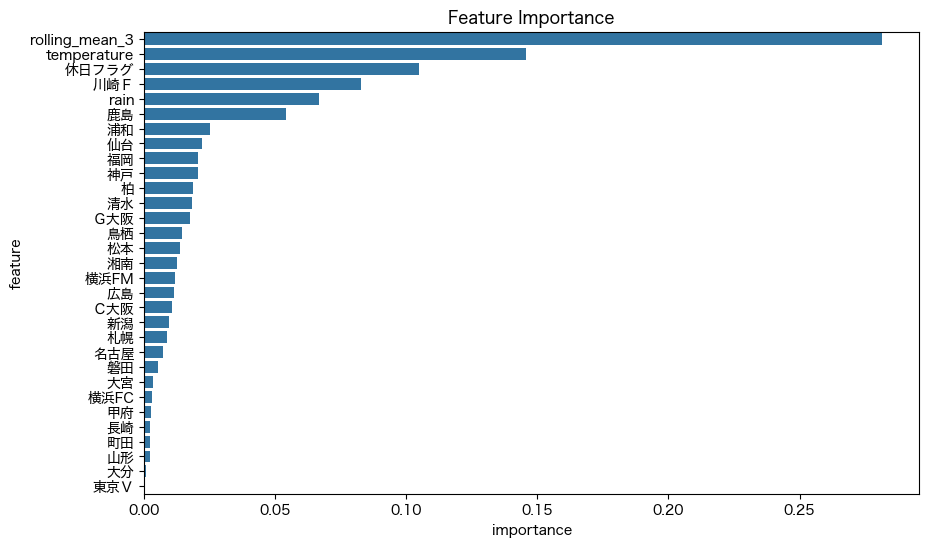

In [52]:
# feature importance
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
feature_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)
plt.rcParams['font.family'] = 'Hiragino Sans' 
plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=feature_importance_df)
plt.title("Feature Importance")
plt.show()

In [59]:
# フィルタリングなし
# ランダムフォレスト 
X = pd.concat([
    pd.get_dummies(df["アウェイ"], drop_first=True).astype(float),
    df[["休日フラグ","コロナ禍ダミー", "国立フラグ","temperature","rain","rolling_mean_3"]].astype(float)
], axis=1)
y = df["入場者数"].astype(float)

from re import A
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 学習データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# モデルの学習
model = RandomForestRegressor(n_estimators=100,  max_features="log2", random_state=42)
model.fit(X_train, y_train)
# 予測
y_pred = model.predict(X_test)
# 評価 r2_score
from sklearn.metrics import r2_score
print("R2:", r2_score(y_test, y_pred))

R2: 0.7923377806078301


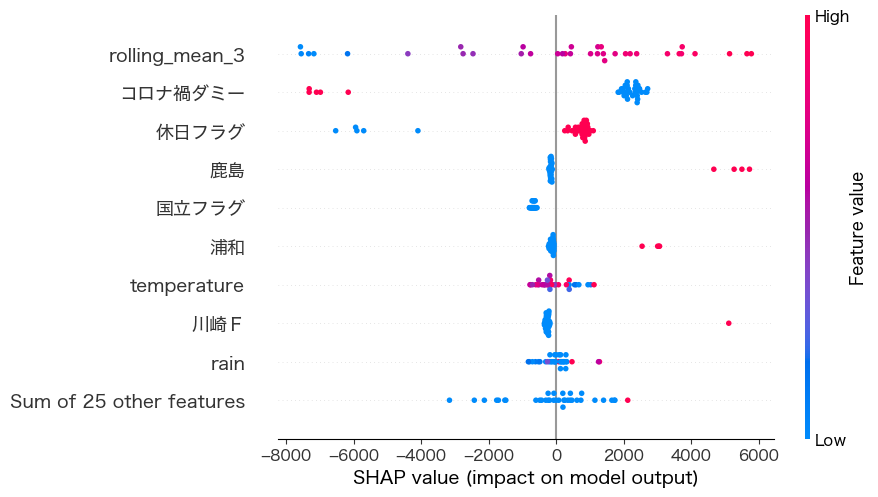

In [61]:
# SHAP図
import shap
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test, check_additivity=False)
shap.plots.beeswarm(shap_values, max_display=10)

In [57]:
# コロナ禍除く
df_noncovid = df[df["コロナ禍ダミー"] == 0]
# ランダムフォレスト
X = pd.concat([
    pd.get_dummies(df_noncovid["アウェイ"], drop_first=True).astype(float),
    df_noncovid[["休日フラグ", "国立フラグ","temperature","rain","rolling_mean_3"]].astype(float)
], axis=1)
y = df_noncovid["入場者数"].astype(float)

from re import A
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 学習データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# モデルの学習
model = RandomForestRegressor(n_estimators=100,  max_features="log2", random_state=42)
model.fit(X_train, y_train)
# 予測
y_pred = model.predict(X_test)
# 評価 r2_score
from sklearn.metrics import r2_score
print("R2:", r2_score(y_test, y_pred))

R2: 0.6510988903783813


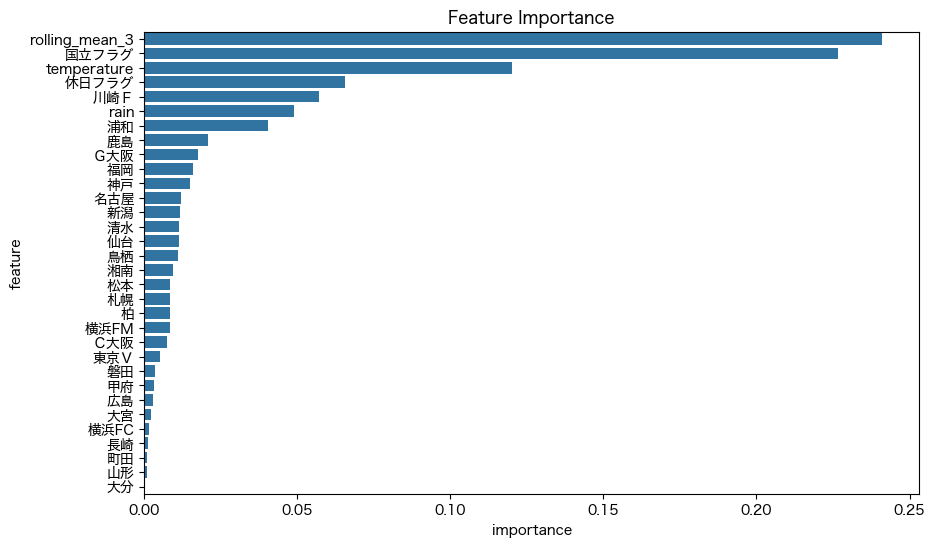

In [58]:
# feature importance
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
feature_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)
plt.rcParams['font.family'] = 'Hiragino Sans' 
plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=feature_importance_df)
plt.title("Feature Importance")
plt.show()

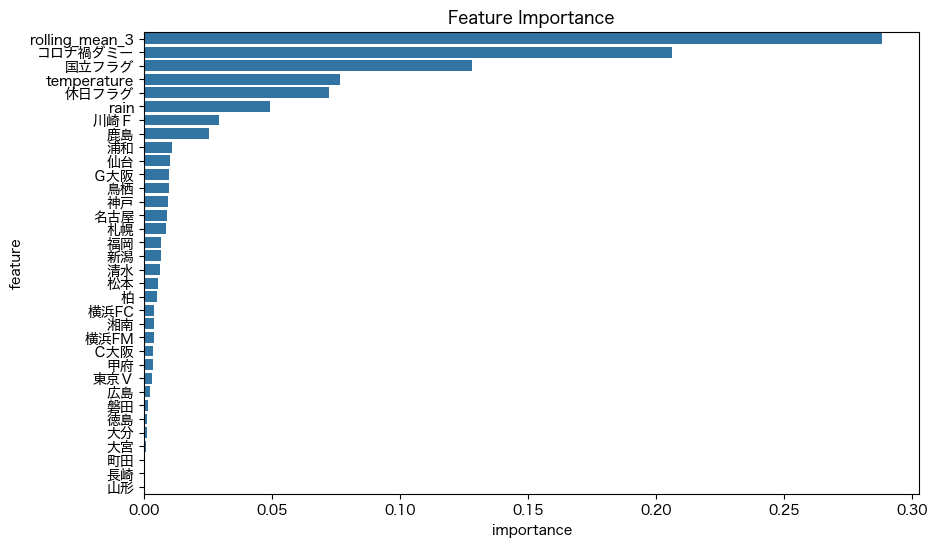

In [54]:
# feature importance
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
feature_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)
plt.rcParams['font.family'] = 'Hiragino Sans' 
plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=feature_importance_df)
plt.title("Feature Importance")
plt.show()

In [55]:
from sklearn.inspection import permutation_importance

# モデルを学習済みとする
r = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=42)

# 結果を表示
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std
}).sort_values("importance_mean", ascending=False)

print(importance_df.head(10))

           feature  importance_mean  importance_std
33  rolling_mean_3         0.424885        0.089322
29         コロナ禍ダミー         0.283793        0.077308
28           休日フラグ         0.151797        0.046778
25              鹿島         0.086634        0.029368
15              浦和         0.071102        0.015297
5              川崎Ｆ         0.035699        0.013340
12               柏         0.017663        0.007046
32            rain         0.016905        0.016212
31     temperature         0.014603        0.012505
24              鳥栖         0.013684        0.008626


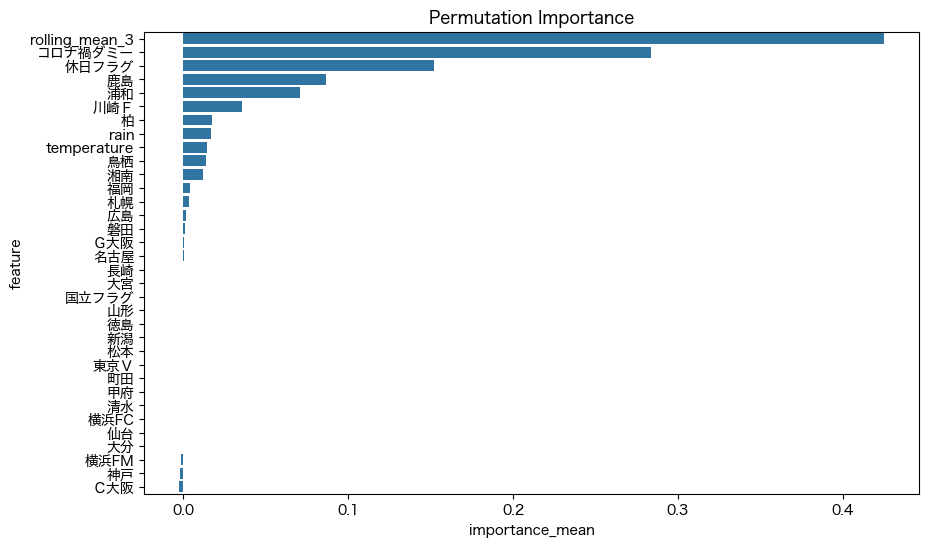

In [56]:
# permutation importanceの可視化
plt.rcParams['font.family'] = 'Hiragino Sans'
plt.figure(figsize=(10, 6))
sns.barplot(x="importance_mean", y="feature", data=importance_df)
plt.title("Permutation Importance")
plt.show()